In [61]:
# Cell 1: Load thư viện và dữ liệu Việt Nam
import pandas as pd
import numpy as np
import os
import torch
import warnings
warnings.filterwarnings("ignore")

# Đường dẫn đến file dữ liệu VN
path_vn_main = "data/processed/VN_data/full_vietnam_monthly.csv"
path_vn_weather = "data/processed/VN_data/full_weather_vietnam_monthly.csv"

# Đọc file
df_main = pd.read_csv(path_vn_main, sep=',')
df_weather = pd.read_csv(path_vn_weather)

print("Columns in main:", list(df_main.columns))
print("Columns in weather:", list(df_weather.columns))

# Merge dữ liệu (Giả sử dự trên Date/tháng và các cột định danh)
# Ta sẽ xem xét cách merge sao cho hợp lý sau khi thấy sơ bộ dữ liệu
display(df_main.head())
display(df_weather.head())


Columns in main: ['entity', 'date', 'series', 'is_aggregate_series', 'generation_twh', 'IPI_Value', 'CPI_Value', 'GDP_VND_Trillion', 'Oil_Price', 'FDI_Disbursed_Monthly(bilionUSD)', 'FDI_Registered_Monthly(bilionUSD)', 'gas_price', 'castlecoal_price', 'castlecoal_vol']
Columns in weather: ['date', 'humidity_mean', 'precip_mean', 'solar_mean', 'temp_mean']


,entity,date,series,is_aggregate_series,generation_twh,IPI_Value,CPI_Value,GDP_VND_Trillion,Oil_Price,FDI_Disbursed_Monthly(bilionUSD),FDI_Registered_Monthly(bilionUSD),gas_price,castlecoal_price,castlecoal_vol
0,Viet Nam,2019-01-01,Coal,False,9.63,134.05,100.1,7700.0,59.27,1.55,1.907,65.28,99.0,1.14K
1,Viet Nam,2019-01-01,Gas,False,4.12,134.05,100.1,7700.0,59.27,1.55,1.907,65.28,99.0,1.14K
2,Viet Nam,2019-01-01,Hydro,False,3.39,134.05,100.1,7700.0,59.27,1.55,1.907,65.28,99.0,1.14K
3,Viet Nam,2019-01-01,Other fossil,False,0.00,134.05,100.1,7700.0,59.27,1.55,1.907,65.28,99.0,1.14K
4,Viet Nam,2019-01-01,Solar,False,0.00,134.05,100.1,7700.0,59.27,1.55,1.907,65.28,99.0,1.14K


,date,humidity_mean,precip_mean,solar_mean,temp_mean
0,2019-01-01,78.634409,107.366667,401.016667,22.087097
1,2019-02-01,78.190476,30.700000,466.336667,24.680952
2,2019-03-01,78.408602,33.866667,522.160000,25.594624
3,2019-04-01,78.155556,109.033333,570.526667,28.315556
4,2019-05-01,80.451613,194.633333,585.696667,28.589247


In [62]:
# Cell 2: Merge dữ liệu và Tạo các feature cần thiết

# Loại bỏ 'Total Generation' trong df_main trước khi merge để tránh leak / tính toán dư thừa
if 'series' in df_main.columns:
    df_main['series'] = df_main['series'].astype(str).str.strip()
    df_main = df_main[~df_main['series'].str.casefold().eq('total generation')].copy()

df_vn = pd.merge(df_main, df_weather, on='date', how='left')

# Đổi lại tên cho khớp chuẩn của file gốc
df_vn = df_vn.rename(columns={
    'generation_twh': 'generation_TWh',
    'precip_mean': 'precipitation',
    'solar_mean': 'solar',
    'humidity_mean': 'humidity',
    'temp_mean': 'temperature'
})

# Chẩn đoán độ thưa của target theo từng series (dùng bản raw trước khi thay epsilon)
raw_target = pd.to_numeric(df_vn['generation_TWh'], errors='coerce').fillna(0)
zero_ratio_by_series = (
    pd.DataFrame({'series': df_vn['series'], 'raw_target': raw_target})
    .groupby('series')['raw_target']
    .apply(lambda s: (s == 0).mean())
    .sort_values(ascending=False)
)
print('Tỷ lệ 0 theo series (raw target):')
print(zero_ratio_by_series)

# Loại series quá sparse để tránh làm hỏng quá trình finetune đa bước
sparse_threshold = 0.60
sparse_series = zero_ratio_by_series[zero_ratio_by_series >= sparse_threshold].index.tolist()
if sparse_series:
    print(f"Loại khỏi train các series quá sparse (>= {sparse_threshold:.0%} số 0): {sparse_series}")
    df_vn = df_vn[~df_vn['series'].isin(sparse_series)].copy()

# Xử lý các điểm dữ liệu = 0 bằng epsilon nhỏ
if 'generation_TWh' in df_vn.columns:
    df_vn['generation_TWh'] = pd.to_numeric(df_vn['generation_TWh'], errors='coerce').fillna(0)
    df_vn['generation_TWh'] = df_vn['generation_TWh'].replace(0, 1e-4).clip(lower=1e-4)

# Đồng bộ Date và tạo time_idx, month...
df_vn['date'] = pd.to_datetime(df_vn['date'])
df_vn = df_vn.sort_values(['entity', 'series', 'date']).reset_index(drop=True)

min_date = df_vn['date'].min()
df_vn['time_idx'] = ((df_vn['date'].dt.year - min_date.year) * 12 + (df_vn['date'].dt.month - min_date.month)).astype(int)
df_vn['month'] = df_vn['date'].dt.month.astype(str)
df_vn['month_sin'] = np.sin(2 * np.pi * df_vn['date'].dt.month / 12.0)
df_vn['month_cos'] = np.cos(2 * np.pi * df_vn['date'].dt.month / 12.0)

# Tạo target lags và rolling cho generation_TWh
def create_lag_roll(group):
    g = group.copy()
    g = g.sort_values('date')
    for lag in [1, 3, 6, 12]:
        g[f'target_lag_{lag}'] = g['generation_TWh'].shift(lag)
    for window in [3, 6, 12]:
        g[f'target_roll_mean_{window}'] = g['generation_TWh'].shift(1).rolling(window, min_periods=1).mean()
        g[f'target_roll_std_{window}'] = g['generation_TWh'].shift(1).rolling(window, min_periods=1).std().fillna(0)
    return g

df_vn = df_vn.groupby(['entity', 'series'], group_keys=False).apply(create_lag_roll)

# Cùng xử lý lag/roll có giá trị 0 thành 1e-4
lag_roll_cols = [c for c in df_vn.columns if 'lag' in c or 'roll' in c]
for c in lag_roll_cols:
    df_vn[c] = df_vn[c].replace(0, 1e-4).clip(lower=1e-4)

# Xử lý missing values theo nhóm
exogenous_fill_cols = [
    'precipitation', 'solar', 'humidity', 'temperature',
    'IPI_Value', 'CPI_Value', 'GDP_VND_Trillion', 'Oil_Price', 'Oil_Change_Percent',
    'FDI_Disbursed_Monthly(bilionUSD)', 'FDI_Registered_Monthly(bilionUSD)'
]

for c in exogenous_fill_cols:
    if c in df_vn.columns:
        df_vn[c] = df_vn.groupby(['entity', 'series'])[c].transform(lambda x: x.ffill().bfill())
        df_vn[c] = df_vn[c].fillna(0)
        q01, q99 = df_vn[c].quantile([0.01, 0.99])
        df_vn[c] = df_vn[c].clip(lower=q01, upper=q99)

# Log-scale một số biến kinh tế có biên độ lớn để ổn định optimization
for c in ['GDP_VND_Trillion', 'Oil_Price', 'FDI_Disbursed_Monthly(bilionUSD)', 'FDI_Registered_Monthly(bilionUSD)']:
    if c in df_vn.columns:
        df_vn[c] = np.log1p(pd.to_numeric(df_vn[c], errors='coerce').fillna(0).clip(lower=0))

for c in lag_roll_cols:
    if c in df_vn.columns:
        df_vn[c] = df_vn.groupby(['entity', 'series'])[c].transform(lambda x: x.ffill())
        df_vn[c] = df_vn[c].fillna(1e-4).clip(lower=1e-4)

print(f"Tổng số records sau lọc: {len(df_vn)}")
print(f"Các loại năng lượng dùng để train: {sorted(df_vn['series'].unique().tolist())}")
display(df_vn.head(3))

Tỷ lệ 0 theo series (raw target):
series
Other fossil    0.736111
Wind            0.138889
Solar           0.041667
Coal            0.000000
Gas             0.000000
Hydro           0.000000
Name: raw_target, dtype: float64
Loại khỏi train các series quá sparse (>= 60% số 0): ['Other fossil']
Tổng số records sau lọc: 360
Các loại năng lượng dùng để train: ['Coal', 'Gas', 'Hydro', 'Solar', 'Wind']


,entity,date,series,is_aggregate_series,generation_TWh,IPI_Value,CPI_Value,GDP_VND_Trillion,Oil_Price,FDI_Disbursed_Monthly(bilionUSD),...,target_lag_1,target_lag_3,target_lag_6,target_lag_12,target_roll_mean_3,target_roll_std_3,target_roll_mean_6,target_roll_std_6,target_roll_mean_12,target_roll_std_12
0,Viet Nam,2019-01-01,Coal,False,9.63,134.05,100.10,8.949105,4.098834,0.936093,...,0.0001,0.0001,0.0001,0.0001,0.0001,0.000100,0.0001,0.000100,0.0001,0.000100
1,Viet Nam,2019-02-01,Coal,False,9.90,108.37,100.80,8.949105,4.176385,0.708036,...,9.6300,0.0001,0.0001,0.0001,9.6300,0.000100,9.6300,0.000100,9.6300,0.000100
2,Viet Nam,2019-03-01,Coal,False,8.43,134.77,99.79,8.949105,4.210793,0.932164,...,9.9000,0.0001,0.0001,0.0001,9.7650,0.190919,9.7650,0.190919,9.7650,0.190919


In [63]:
# Cell 3: Chuẩn bị Dataset và Dataloader cho VN
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer

max_encoder_length = 36
max_prediction_length = 12  # Giảm horizon để tăng độ ổn định và số mẫu train hữu ích
batch_size = 16

# Kiểm tra độ dài
series_lengths = df_vn.groupby(['entity', 'series'])['time_idx'].nunique().reset_index(name='n_steps')
min_required_length = max_encoder_length + max_prediction_length
valid_groups = series_lengths.loc[series_lengths['n_steps'] >= min_required_length, ['entity', 'series']]
df_vn_valid = df_vn.merge(valid_groups, on=['entity', 'series'], how='inner').copy()

training_cutoff = df_vn_valid['time_idx'].max() - max_prediction_length

# Phân chia feature tránh hiện tượng data leakage
known_candidates = [
    'time_idx', 'month_sin', 'month_cos',
    'precipitation', 'solar', 'humidity', 'temperature',
]

# Giảm bớt biến dễ gây nhiễu để ưu tiên ổn định trước
unknown_candidates = [
    'generation_TWh',
    'target_lag_1', 'target_lag_3', 'target_lag_6', 'target_lag_12',
    'target_roll_mean_3', 'target_roll_mean_6', 'target_roll_mean_12',
    'target_roll_std_3', 'target_roll_std_6', 'target_roll_std_12',
    'IPI_Value', 'CPI_Value', 'GDP_VND_Trillion',
    'Oil_Price',
    'FDI_Disbursed_Monthly(bilionUSD)', 'FDI_Registered_Monthly(bilionUSD)'
]

known_reals = [c for c in known_candidates if c in df_vn_valid.columns]
unknown_reals = [c for c in unknown_candidates if c in df_vn_valid.columns]

training = TimeSeriesDataSet(
    df_vn_valid[lambda x: x.time_idx <= training_cutoff],
    time_idx='time_idx',
    target='generation_TWh',
    group_ids=['entity', 'series'],
    min_encoder_length=max_encoder_length // 2,
    max_encoder_length=max_encoder_length,
    min_prediction_length=max_prediction_length,
    max_prediction_length=max_prediction_length,
    static_categoricals=['entity', 'series'],
    time_varying_known_categoricals=['month'],
    time_varying_known_reals=known_reals,
    time_varying_unknown_reals=unknown_reals,
    target_normalizer=GroupNormalizer(groups=['entity', 'series']),
    lags={'generation_TWh': [1, 2, 3, 6, 12]},
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True,
)

validation = TimeSeriesDataSet.from_dataset(
    training,
    df_vn_valid,
    min_prediction_idx=training_cutoff + 1,
    stop_randomization=True,
)

train_loader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_loader = validation.to_dataloader(train=False, batch_size=batch_size * 2, num_workers=0)

print("Đã tạo xong DataLoaders cho VN dataset")
print(f"Số cửa sổ train: {len(training)} | validation: {len(validation)}")

Đã tạo xong DataLoaders cho VN dataset
Số cửa sổ train: 185 | validation: 95


In [64]:
# Cell 4: Transfer Learning - Load pretrained weights và Đóng băng (Freeze)
from pytorch_forecasting.metrics import QuantileLoss

# 1. Khởi tạo mô hình tương thích checkpoint pretrained để tận dụng transfer tối đa
# (Giữ kiến trúc gần bản gốc để tỷ lệ load weight trùng khớp cao)
tft_vn = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=1e-4,
    hidden_size=64,
    attention_head_size=4,
    dropout=0.10,
    hidden_continuous_size=32,
    loss=QuantileLoss(),
    log_interval=50,
    reduce_on_plateau_patience=3,
    optimizer='adamw',
    weight_decay=1e-3,
)
print("Đã khởi tạo model TFT theo cấu hình tương thích pretrained.")

# 2. Load pretrained weights trùng khớp tên + shape
checkpoint_path = "checkpoint/tft_model_best.ckpt"
pretrained_dict = torch.load(checkpoint_path, map_location=tft_vn.device, weights_only=False)['state_dict']
model_dict = tft_vn.state_dict()

matched_dict = {k: v for k, v in pretrained_dict.items() if k in model_dict and v.shape == model_dict[k].shape}
model_dict.update(matched_dict)
tft_vn.load_state_dict(model_dict)

n_match_tensors = len(matched_dict)
n_total_tensors = len(model_dict)
match_tensor_ratio = n_match_tensors / max(n_total_tensors, 1)
n_match_params = sum(v.numel() for v in matched_dict.values())
n_total_params = sum(v.numel() for v in model_dict.values())
match_param_ratio = n_match_params / max(n_total_params, 1)

print(f"Load pretrained tensors: {n_match_tensors}/{n_total_tensors} ({match_tensor_ratio:.2%})")
print(f"Load pretrained params : {n_match_params}/{n_total_params} ({match_param_ratio:.2%})")

# 3. Stage 1: đóng băng backbone quan trọng để mô hình thích nghi feature mới trước
layers_to_freeze = [
    "lstm_encoder",
    "lstm_decoder",
    "multihead_attn",
    "post_attn_norm"
]

frozen_params = 0
unfrozen_params = 0
for name, param in tft_vn.named_parameters():
    freeze_this = any(f_name in name for f_name in layers_to_freeze)
    if freeze_this:
        param.requires_grad = False
        frozen_params += param.numel()
    else:
        param.requires_grad = True
        unfrozen_params += param.numel()

print(f"---------------------------------------------------")
print(f"Tham số BỊ ĐÓNG BĂNG (Freezed): {frozen_params/1000:.1f} k")
print(f"Tham số FINETUNE (Unfreezed)  : {unfrozen_params/1000:.1f} k")
print(f"---------------------------------------------------")

Đã khởi tạo model TFT theo cấu hình tương thích pretrained.
Load pretrained tensors: 626/756 (82.80%)
Load pretrained params : 453783/540795 (83.91%)
---------------------------------------------------
Tham số BỊ ĐÓNG BĂNG (Freezed): 76.9 k
Tham số FINETUNE (Unfreezed)  : 452.7 k
---------------------------------------------------


In [65]:
# Cell 5: Tiến hành Fineturn (Train) model trên dữ liệu Việt Nam (2 giai đoạn)
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor, ModelCheckpoint

pl.seed_everything(42, workers=True)
accelerator_type = 'gpu' if torch.cuda.is_available() else 'cpu'

# ===== Stage 1: Train head với backbone đang freeze =====
print("Bắt đầu Stage 1 (head-only finetune)...")
early_stop_stage1 = EarlyStopping(monitor='val_loss', min_delta=1e-5, patience=6, verbose=True, mode='min')
lr_logger_stage1 = LearningRateMonitor()
ckpt_stage1 = ModelCheckpoint(
    monitor='val_loss',
    mode='min',
    filename='tft_vn_stage1_best-{epoch:02d}-{val_loss:.4f}',
    save_top_k=1,
)

trainer_stage1 = pl.Trainer(
    max_epochs=15,
    accelerator=accelerator_type,
    devices=1,
    gradient_clip_val=0.1,
    callbacks=[lr_logger_stage1, early_stop_stage1, ckpt_stage1],
    enable_model_summary=True,
)
trainer_stage1.fit(tft_vn, train_dataloaders=train_loader, val_dataloaders=val_loader)

# ===== Stage 2: Unfreeze toàn bộ và finetune nhẹ =====
print("Bắt đầu Stage 2 (full finetune ổn định)...")
for _, param in tft_vn.named_parameters():
    param.requires_grad = True

# LR thấp để tinh chỉnh tránh phá pretrained knowledge
if hasattr(tft_vn, 'hparams') and hasattr(tft_vn.hparams, 'learning_rate'):
    tft_vn.hparams.learning_rate = 3e-5
if hasattr(tft_vn, 'learning_rate'):
    tft_vn.learning_rate = 3e-5

early_stop_stage2 = EarlyStopping(monitor='val_loss', min_delta=1e-5, patience=10, verbose=True, mode='min')
lr_logger_stage2 = LearningRateMonitor()
best_ckpt_cb = ModelCheckpoint(
    dirpath='checkpoint',
    monitor='val_loss',
    mode='min',
    filename='tft_vn_best-{epoch:02d}-{val_loss:.4f}',
    save_top_k=1,
)

trainer_stage2 = pl.Trainer(
    max_epochs=60,
    accelerator=accelerator_type,
    devices=1,
    gradient_clip_val=0.1,
    callbacks=[lr_logger_stage2, early_stop_stage2, best_ckpt_cb],
    enable_model_summary=True,
)

trainer_stage2.fit(
    tft_vn,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader,
)

# Giữ tên trainer_vn để tương thích các cell sau
trainer_vn = trainer_stage2

print("Đánh giá sau Finetune...")
metrics = trainer_vn.validate(tft_vn, dataloaders=val_loader)
print("Kết quả Finetune (VN dataset):", metrics)

Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Bắt đầu Stage 1 (head-only finetune)...


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │     93 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │  2.1 K │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │ 21.2 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  236 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │ 64.6 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │ 33.3 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │ 33.3 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  8.3 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │    128 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │ 20.9 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │ 10.4 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    455 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 452 K                                                                                            
Non-trainable params: 76.9 K                                                                                       
Total params: 529 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 801                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

Monitored metric val_loss did not improve in the last 10 records. Best score: 0.676. Signaling Trainer to stop.


Output()

Đánh giá sau Finetune...


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          val_MAE          │    1.0313092470169067     │
│         val_MAPE          │    0.26448312401771545    │
│         val_RMSE          │    1.3747695684432983     │
│         val_SMAPE         │    0.24077622592449188    │
│         val_loss          │    0.7087100148200989     │
└───────────────────────────┴───────────────────────────┘

Kết quả Finetune (VN dataset): [{'val_loss': 0.7087100148200989, 'val_SMAPE': 0.24077622592449188, 'val_MAE': 1.0313092470169067, 'val_RMSE': 1.3747695684432983, 'val_MAPE': 0.26448312401771545}]


Load best checkpoint để đánh giá: C:\Users\ADMIN\Downloads\MODEL_TFT\checkpoint\tft_vn_best-epoch=04-val_loss=0.6764.ckpt


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightn

--- KẾT QUẢ ĐÁNH GIÁ (TẬP VALIDATION VN) ---
Validation MAE : 1.0237
Validation RMSE: 1.5889
Validation WAPE: 19.9249%
Validation R2  : 0.8929


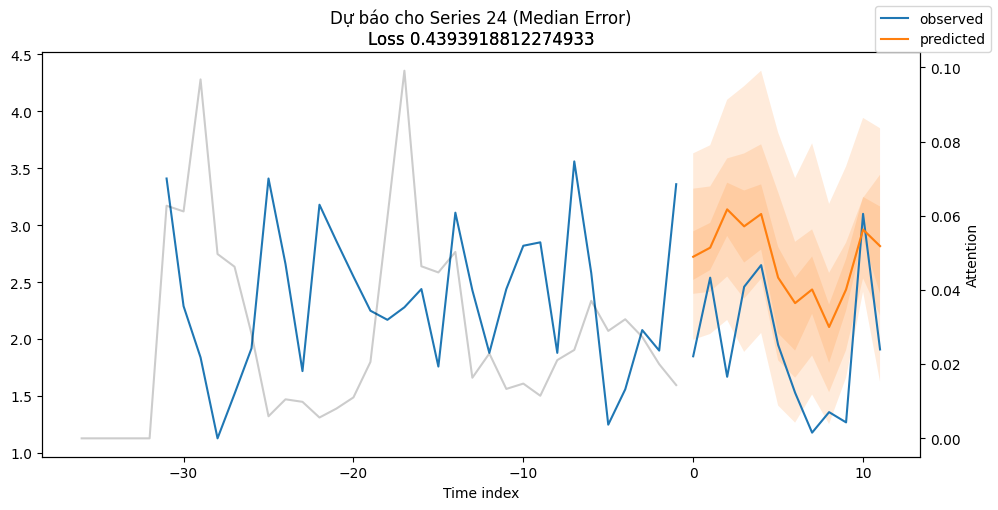

In [66]:
# Cell 6: Đánh giá chi tiết (Metrics & Biểu đồ) sau khi Transfer Learning
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Nếu có best checkpoint thì load trước khi đánh giá
if 'best_ckpt_cb' in globals() and getattr(best_ckpt_cb, 'best_model_path', None):
    best_eval_path = best_ckpt_cb.best_model_path
    if best_eval_path and os.path.exists(best_eval_path):
        print(f"Load best checkpoint để đánh giá: {best_eval_path}")
        try:
            tft_vn = TemporalFusionTransformer.load_from_checkpoint(best_eval_path, weights_only=False)
        except TypeError:
            # Tương thích phiên bản Lightning/PyTorch cũ không hỗ trợ tham số weights_only
            tft_vn = TemporalFusionTransformer.load_from_checkpoint(best_eval_path)
        except Exception as e:
            print(f"Không load được best checkpoint ({e}). Sẽ dùng model hiện tại trong RAM để đánh giá.")

# Tắt gradient khi dự báo
torch.set_grad_enabled(False)
raw_pred_obj = tft_vn.predict(val_loader, mode='raw', return_x=True)

if hasattr(raw_pred_obj, 'output'):
    raw_predictions = raw_pred_obj.output
    x = getattr(raw_pred_obj, 'x', None)
elif isinstance(raw_pred_obj, tuple):
    raw_predictions = raw_pred_obj[0]
    x = raw_pred_obj[1] if len(raw_pred_obj) > 1 else None
else:
    raw_predictions = raw_pred_obj
    x = None

point_pred_obj = tft_vn.predict(val_loader, mode='prediction')
point_predictions = point_pred_obj.output if hasattr(point_pred_obj, 'output') else point_pred_obj

# Lấy actuals an toàn khi prediction length có thể không đồng nhất giữa các sample
if isinstance(x, dict) and 'decoder_target' in x:
    actuals = x['decoder_target']
else:
    # Fallback: nối theo vector 1D để tránh lỗi mismatch chiều thời gian
    actuals = torch.cat([y[0].reshape(-1) for _, y in iter(val_loader)], dim=0)

# Chuẩn hóa về vector 1D để tính metric ổn định
actuals_flat = actuals.detach().cpu().reshape(-1)
preds_flat = point_predictions.detach().cpu().reshape(-1)

n = min(actuals_flat.shape[0], preds_flat.shape[0])
if n == 0:
    raise RuntimeError("Không có dữ liệu để đánh giá trên validation set.")

actuals_flat = actuals_flat[:n]
preds_flat = preds_flat[:n]

# Lọc NaN/Inf trước khi tính metrics để tránh crash (thường xảy ra ở một vài điểm dự báo bất thường)
finite_mask = torch.isfinite(actuals_flat) & torch.isfinite(preds_flat)
valid_count = int(finite_mask.sum().item())
if valid_count == 0:
    raise RuntimeError("Toàn bộ điểm dự báo/nhãn trên validation chứa NaN hoặc Inf, không thể đánh giá.")

if valid_count < n:
    print(f"Cảnh báo: đã bỏ {n - valid_count} điểm NaN/Inf trước khi tính metrics.")

actuals_valid = actuals_flat[finite_mask]
preds_valid = preds_flat[finite_mask]

# Tính toán các metrics
mae = (actuals_valid - preds_valid).abs().mean().item()
rmse = torch.sqrt(((actuals_valid - preds_valid) ** 2).mean()).item()
wape = ((actuals_valid - preds_valid).abs().sum() / (actuals_valid.abs().sum() + 1e-8)).item() * 100

y_true_np = actuals_valid.numpy()
y_pred_np = preds_valid.numpy()

# R2 yêu cầu ít nhất 2 mẫu hợp lệ
if y_true_np.shape[0] >= 2:
    r2 = r2_score(y_true_np, y_pred_np)
else:
    r2 = float('nan')
    print("Cảnh báo: số điểm hợp lệ < 2 nên R2 không xác định.")

print(f"--- KẾT QUẢ ĐÁNH GIÁ (TẬP VALIDATION VN) ---")
print(f'Validation MAE : {mae:.4f}')
print(f'Validation RMSE: {rmse:.4f}')
print(f'Validation WAPE: {wape:.4f}%')
print(f'Validation R2  : {r2:.4f}')

# Vẽ biểu đồ median-error chỉ khi shape 2D khớp nhau
can_plot = (
    isinstance(actuals, torch.Tensor)
    and isinstance(point_predictions, torch.Tensor)
    and actuals.ndim == 2
    and point_predictions.ndim == 2
    and actuals.shape == point_predictions.shape
)

if can_plot and len(actuals) > 0:
    err_per_series = (actuals - point_predictions).abs().mean(dim=1)
    idx_plot = int(torch.argsort(err_per_series)[len(err_per_series) // 2].item())

    if x is not None:
        fig, ax = plt.subplots(figsize=(10, 5))
        _ = tft_vn.plot_prediction(x, raw_predictions, idx=idx_plot, add_loss_to_title=True, ax=ax)
        plt.title(f"Dự báo cho Series {idx_plot} (Median Error)\n" + ax.get_title())
        plt.show()
else:
    print("Bỏ qua biểu đồ median-error vì prediction length không đồng nhất giữa các sample validation.")

In [67]:
# Cell 7: Lưu cấu hình và model sau Transfer Learning
import shutil
import os

# Tạo thư mục checkpoint nếu chưa có
os.makedirs("checkpoint", exist_ok=True)

model_save_path = "checkpoint/tft_vn_model_best.ckpt"

# Lưu state cuối cùng
trainer_vn.save_checkpoint("checkpoint/tft_vn_model_latest.ckpt")
print("Đã lưu mô hình mới nhất (cuối quá trình Finetune) tại: checkpoint/tft_vn_model_latest.ckpt")

# Ưu tiên checkpoint tốt nhất từ callback stage 2
best_path = None
if 'best_ckpt_cb' in globals() and best_ckpt_cb is not None:
    best_path = getattr(best_ckpt_cb, 'best_model_path', None)

# Fallback nếu không có best_ckpt_cb
if not best_path and trainer_vn.checkpoint_callback:
    best_path = getattr(trainer_vn.checkpoint_callback, 'best_model_path', None)

if best_path and os.path.exists(best_path):
    print(f"File checkpoint tốt nhất (theo val_loss): {best_path}")
    shutil.copy(best_path, model_save_path)
    print(f"Đã copy mô hình tốt nhất (Finetuned) sang: {model_save_path}")
else:
    print("Không tìm thấy checkpoint tốt nhất. Bạn có thể dùng bản tft_vn_model_latest.ckpt ở trên.")

# Để load lại dùng dự báo ở file khác:
# from pytorch_forecasting import TemporalFusionTransformer
# loaded_tft_vn = TemporalFusionTransformer.load_from_checkpoint("checkpoint/tft_vn_model_best.ckpt")

`weights_only` was not set, defaulting to `False`.


Đã lưu mô hình mới nhất (cuối quá trình Finetune) tại: checkpoint/tft_vn_model_latest.ckpt
File checkpoint tốt nhất (theo val_loss): C:\Users\ADMIN\Downloads\MODEL_TFT\checkpoint\tft_vn_best-epoch=04-val_loss=0.6764.ckpt
Đã copy mô hình tốt nhất (Finetuned) sang: checkpoint/tft_vn_model_best.ckpt


In [68]:
# Cell 8: Chẩn đoán nhanh nguyên nhân hiệu năng
print('max_prediction_length =', max_prediction_length)
print('sparse_series removed =', sparse_series if 'sparse_series' in globals() else None)
print('train_windows =', len(training), '| val_windows =', len(validation))

if 'matched_dict' in globals() and 'model_dict' in globals():
    n_match_tensors = len(matched_dict)
    n_total_tensors = len(model_dict)
    match_tensor_ratio = n_match_tensors / max(n_total_tensors, 1)
    n_match_params = sum(v.numel() for v in matched_dict.values())
    n_total_params = sum(v.numel() for v in model_dict.values())
    match_param_ratio = n_match_params / max(n_total_params, 1)
    print('pretrained tensor match =', f'{n_match_tensors}/{n_total_tensors}', f'({match_tensor_ratio:.2%})')
    print('pretrained param match  =', f'{n_match_params}/{n_total_params}', f'({match_param_ratio:.2%})')

if 'best_ckpt_cb' in globals() and best_ckpt_cb is not None:
    print('best ckpt path =', getattr(best_ckpt_cb, 'best_model_path', None))

if 'valid_count' in globals() and 'n' in globals():
    print('valid eval points =', valid_count, '/', n, f'({valid_count/max(n,1):.2%})')

max_prediction_length = 12
sparse_series removed = ['Other fossil']
train_windows = 185 | val_windows = 95
pretrained tensor match = 626/756 (82.80%)
pretrained param match  = 453783/540795 (83.91%)
best ckpt path = C:\Users\ADMIN\Downloads\MODEL_TFT\checkpoint\tft_vn_best-epoch=04-val_loss=0.6764.ckpt
valid eval points = 1140 / 1140 (100.00%)
